# Alpha-factor affected regions

Show the resolution and pervasiveness of regions of the chromatin in which alpha-factor affects S and G2/M. Is this occurring on a per-nucleosome basis? Or does this occur per larger windows of the genome 1-10k. 

**Motivation**
The downstream analysis is affected by the modeling limitation that the recovery phase of S/G2M doesn't appear the be similar to the mother and daughter S/G2M for many/not all regions of the genome. This may be a significant source of elevated read counts in CG1 compared to S/G2M.

**Procedure**
1. Load the 10k/2k-stride region of chromosome 4.
2. Compute the first and second cell cycle lengths
3. Compute the correlation between the first and second cell cycles
4. Identify the highest and lowest correlation regions
5. Once classified, examine the deconvolution results for the highest and lowest regions.
6. *Determine the resolution of the alpha-factor regions.*

**Notes**
- Other ideas around CG1-S/G2M behavior may be around copy number correction.
- The hope is the be able to separate the copy number correction affect from the recovery/alpha factor modeling limitation.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis = MNaseOriginAnalysis()

replicate = 1
chromosome = 10

mnase_analysis.load_mnase_data(replicate, chromosome)
mnase_analysis.compute_sliding_window_counts_all_times()


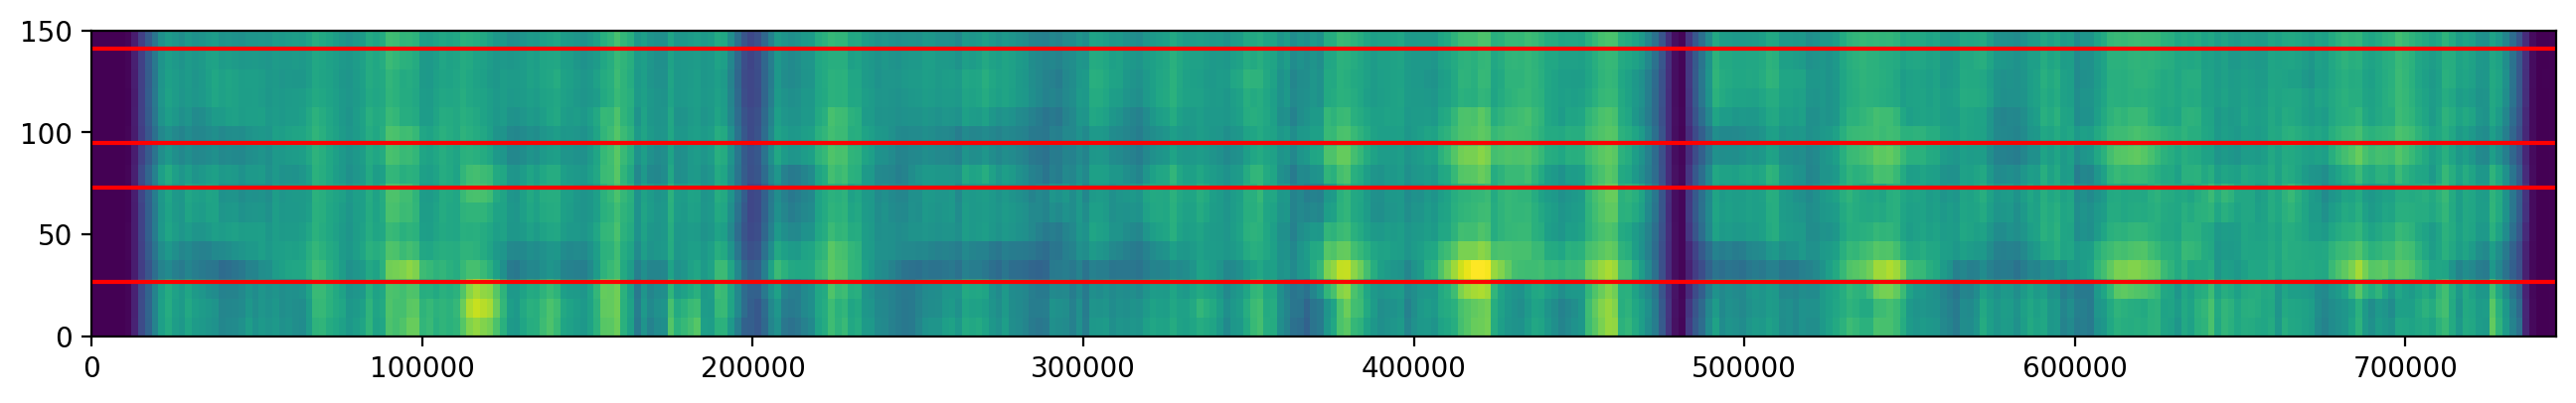

In [69]:
from src.helpers import normalize_sum_ndarray
from src.global_config import GlobalConstants
from src.sgd import get_chromosome_length
from src.config import load_configs_by_config_type

chrom_len = get_chromosome_length(mnase_analysis.chromosome)
normalized_read_counts = normalize_sum_ndarray(mnase_analysis.all_counts_unnormalized)

# todo: this should be a dataframe to begin with
normalized_read_counts_df = pd.DataFrame(normalized_read_counts.T, index=mnase_analysis.start_indices, columns=timepoints)

plt.figure(figsize=(16, 2))
plt.imshow(normalized_read_counts_df.T, aspect='auto', origin='lower',
          extent=[0, chrom_len, 
                  GlobalConstants.CHROM_WT1_TIMEPOINTS[0], 
                  GlobalConstants.CHROM_WT1_TIMEPOINTS[-1]])

# Load the timepoints for the first and second cell cycles
# We are interested in the time from the start of S to the end of G2M
config, _ = load_configs_by_config_type('shared')

(g1_recovery_would_start_here, cg1_length, lambda_len,\
s_length, mu0, first_s_start, first_s_send, end_first_lambd) \
    = config.get_key_timepoints_in_raw(full=True)

cc1 = first_s_start, end_first_lambd
cc2 = end_first_lambd+cg1_length, end_first_lambd+lambda_len

plt.axhline(cc1[0], c='red')
plt.axhline(cc1[1], c='red')

plt.axhline(cc2[0], c='red')
plt.axhline(cc2[1], c='red')

In [49]:
# Which timepoints should we select for each cell cycle?
timepoints = np.array(GlobalConstants.CHROM_WT1_TIMEPOINTS)
cc1_timepoints = timepoints[(timepoints >= cc1[0]) & (timepoints <= cc1[1])]
cc2_timepoints = timepoints[(timepoints >= cc2[0]) & (timepoints <= cc2[1])]

cc1_timepoints, cc2_timepoints

(16, 368)

In [66]:
from scipy.stats import pearsonr

cc_1_2_correlation = normalized_read_counts_df[[]].copy()

for start_index, row in normalized_read_counts_df.iterrows():
    first_cc_occ = row[cc1_timepoints]
    second_cc_occ = row[cc2_timepoints]
    correlation, pval = pearsonr(first_cc_occ, second_cc_occ)
    cc_1_2_correlation.loc[start_index, 'pearsonr'] = correlation
    cc_1_2_correlation.loc[start_index, 'pvalue'] = pval
    cc_1_2_correlation.loc[start_index, 'cc1_occ'] = first_cc_occ.sum()
    cc_1_2_correlation.loc[start_index, 'cc2_occ'] = second_cc_occ.sum()


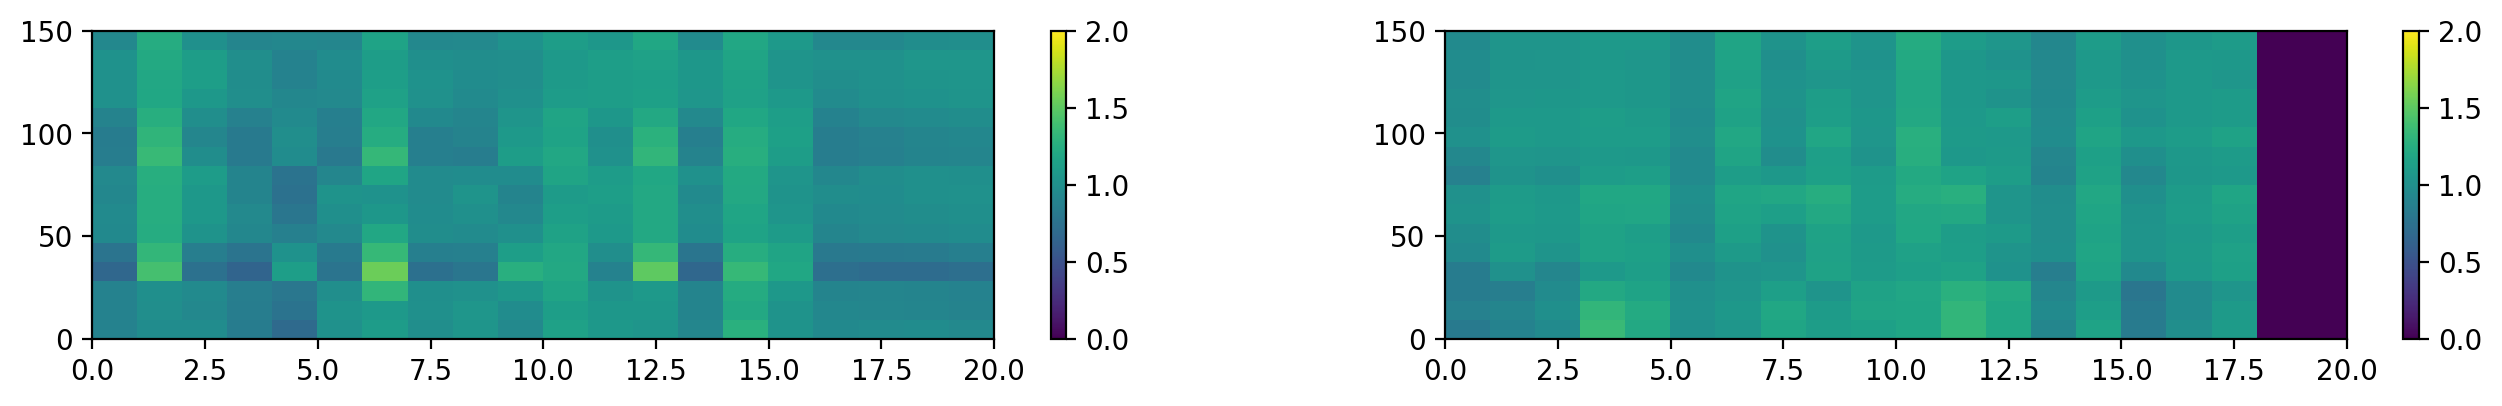

In [76]:
windows_sorted_by_correlation = cc_1_2_correlation.sort_values('pearsonr')

# Plot the high and low correlation regions
high_corr = windows_sorted_by_correlation.tail(20).index
low_corr = windows_sorted_by_correlation.head(20).index

plt.figure(figsize=(16, 2))
plt.subplot(1, 2, 1)
plt.imshow(normalized_read_counts_df.loc[high_corr].T, aspect='auto', origin='lower',
          extent=[0, len(high_corr), 
                  GlobalConstants.CHROM_WT1_TIMEPOINTS[0], 
                  GlobalConstants.CHROM_WT1_TIMEPOINTS[-1]],
          vmin=0, vmax=2)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(normalized_read_counts_df.loc[low_corr].T, aspect='auto', origin='lower',
          extent=[0, len(low_corr), 
                  GlobalConstants.CHROM_WT1_TIMEPOINTS[0], 
                  GlobalConstants.CHROM_WT1_TIMEPOINTS[-1]],
          vmin=0, vmax=2)
plt.colorbar()

(0.0, 745751.0)

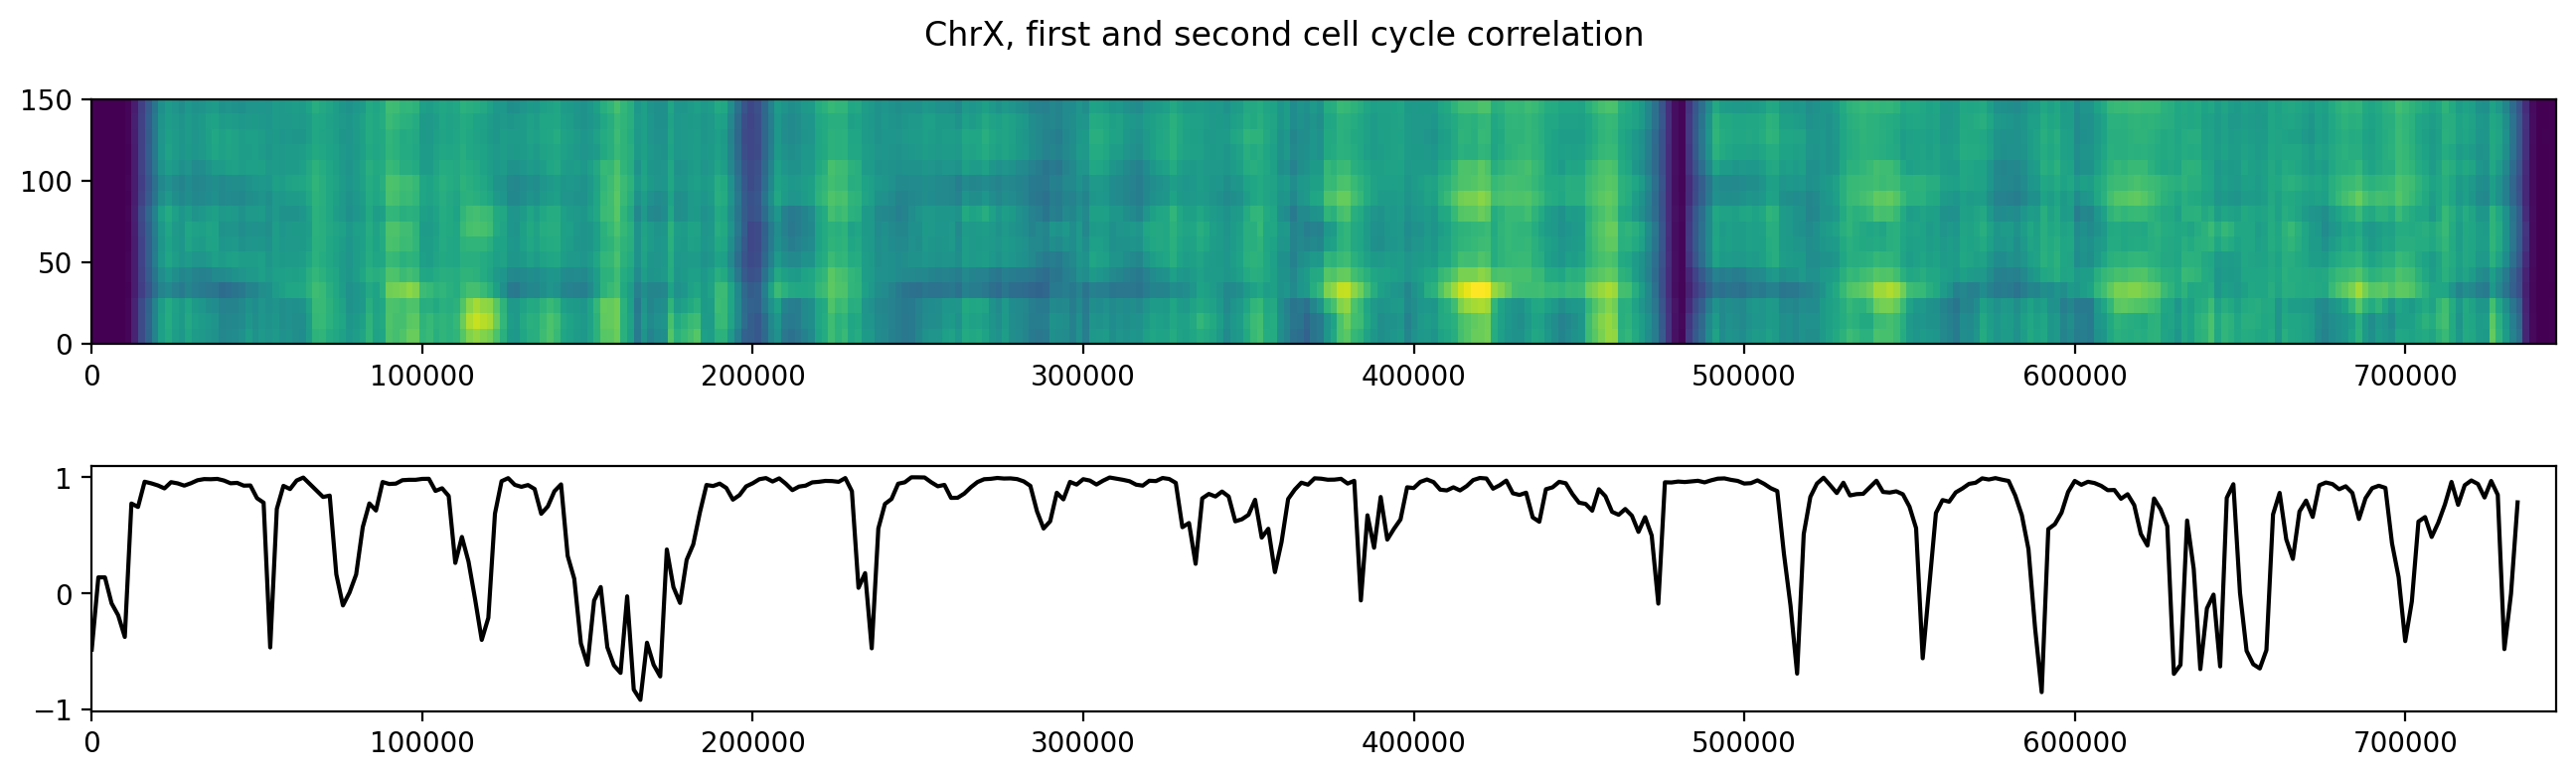

In [105]:
windows_sorted_by_correlation = cc_1_2_correlation.sort_values('pearsonr')

# Plot the high and low correlation regions
high_corr = windows_sorted_by_correlation.tail(20).index
low_corr = windows_sorted_by_correlation.head(20).index

plt.figure(figsize=(16, 4))
plt.subplot(2, 1, 1)
plt.imshow(normalized_read_counts_df.T, aspect='auto', origin='lower',
          extent=[0, chrom_len, 
                  GlobalConstants.CHROM_WT1_TIMEPOINTS[0], 
                  GlobalConstants.CHROM_WT1_TIMEPOINTS[-1]])
plt.subplot(2, 1, 2)
plt.plot(cc_1_2_correlation.index, cc_1_2_correlation.pearsonr, c='black')

plt.suptitle("ChrX, first and second cell cycle correlation")
plt.subplots_adjust(hspace=0.5)
plt.xlim(0, chrom_len)

There are indeed regions in which there alpha factor has a larger effect on the deconvolution.
Interestingly, large amounts of the chromosome have consistent first and second cell cycles, which is promising. 

It's possible that we may be able to filter out the alpha factor affected regions to identify the cleanest deconvolution data set.


In [116]:
# Select regions with the greatest and least correlation and compare the
# deconvolved chromatin plots

# Select the 10k stride windows, we may want to go more granular at some point, but
# there are large swathes of highly correlated regions

start_indices_10k = np.arange(0, chrom_len-10000, 10000)

windows_sorted_by_correlation_stride_10k = \
    windows_sorted_by_correlation.loc[start_indices_10k].sort_values('pearsonr')

low_corr_recovery_region = 160000
high_corr_region = 250000

In [123]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genome_deconv = GenomeDeconvolutionAnalysis('output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/')

In [153]:
deconv_dat_high, deconv_span_high = genome_deconv.load_mnase_span(chromosome, (high_corr_region, high_corr_region+10000))
deconv_dat_low, deconv_span_low = genome_deconv.load_mnase_span(chromosome, (low_corr_recovery_region, low_corr_recovery_region+10000))

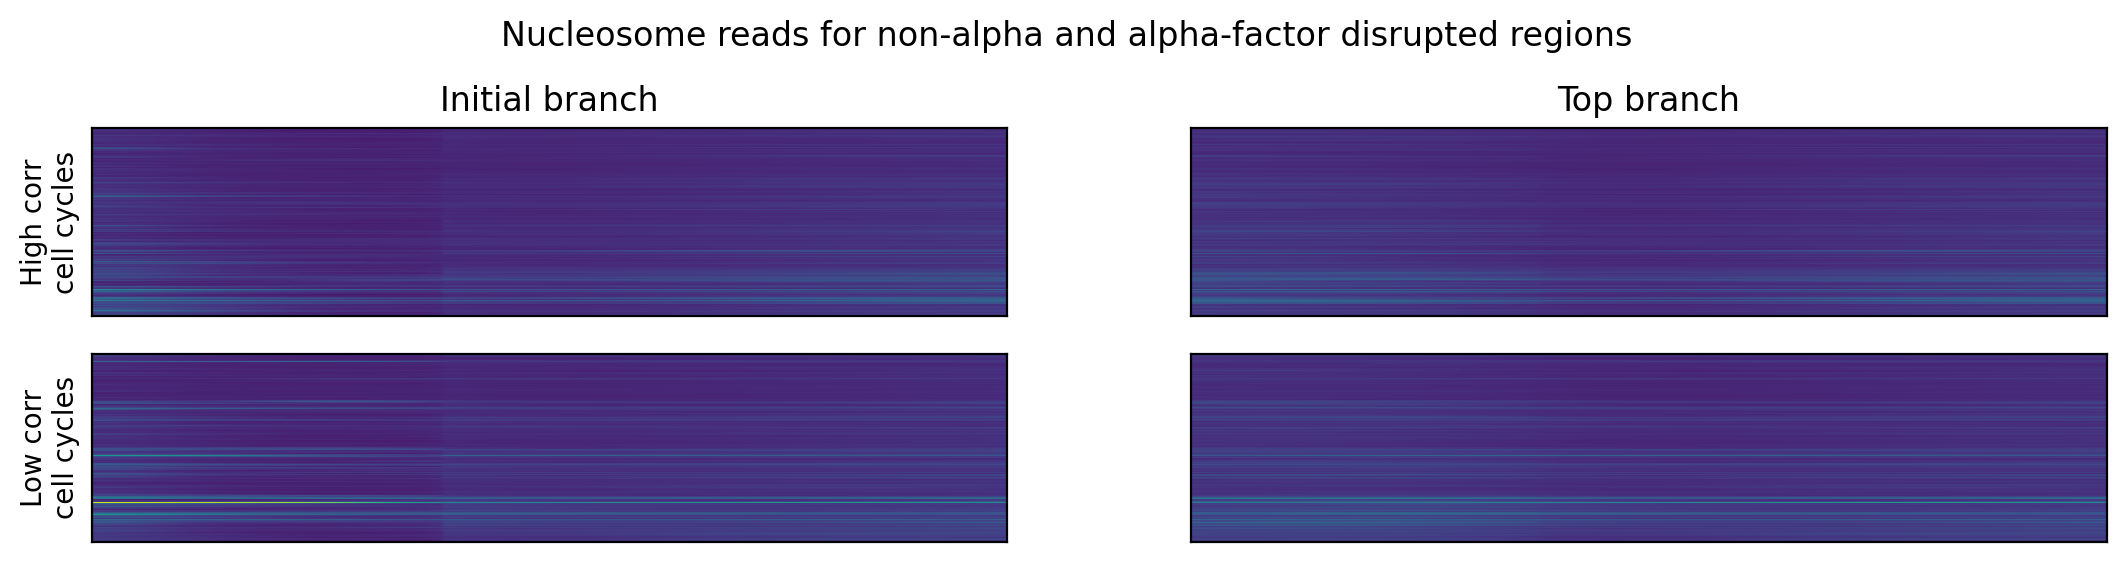

In [152]:

t_indices = config.get_Hpositions_for_branch('t')
i_indices = config.get_Hpositions_for_branch('i')

len_i, len_t = len(i_indices), len(t_indices)

plt.figure(figsize=(13, 3))
plt.subplot(2, 2, 1)
plt.imshow(deconv_dat_high[i_indices, 12:16, :].reshape((len_i, -1)).T, aspect='auto', vmax=10)
plt.xticks([])
plt.yticks([])
plt.title("Initial branch")
plt.ylabel("High corr\ncell cycles")

plt.subplot(2, 2, 2)
plt.imshow(deconv_dat_high[t_indices, 12:16, :].reshape((len_t, -1)).T, aspect='auto', vmax=10)
plt.xticks([])
plt.yticks([])
plt.title("Top branch")

plt.subplot(2, 2, 3)
plt.imshow(deconv_dat_low[i_indices, 12:16, :].reshape((len_i, -1)).T, aspect='auto', vmax=10)
plt.xticks([])
plt.yticks([])
plt.ylabel("Low corr\ncell cycles")

plt.subplot(2, 2, 4)
plt.imshow(deconv_dat_low[t_indices, 12:16, :].reshape((len_t, -1)).T, aspect='auto', vmax=10)
plt.xticks([])
plt.yticks([])

plt.suptitle("Nucleosome reads for non-alpha and alpha-factor disrupted regions")
plt.subplots_adjust(top=0.8)

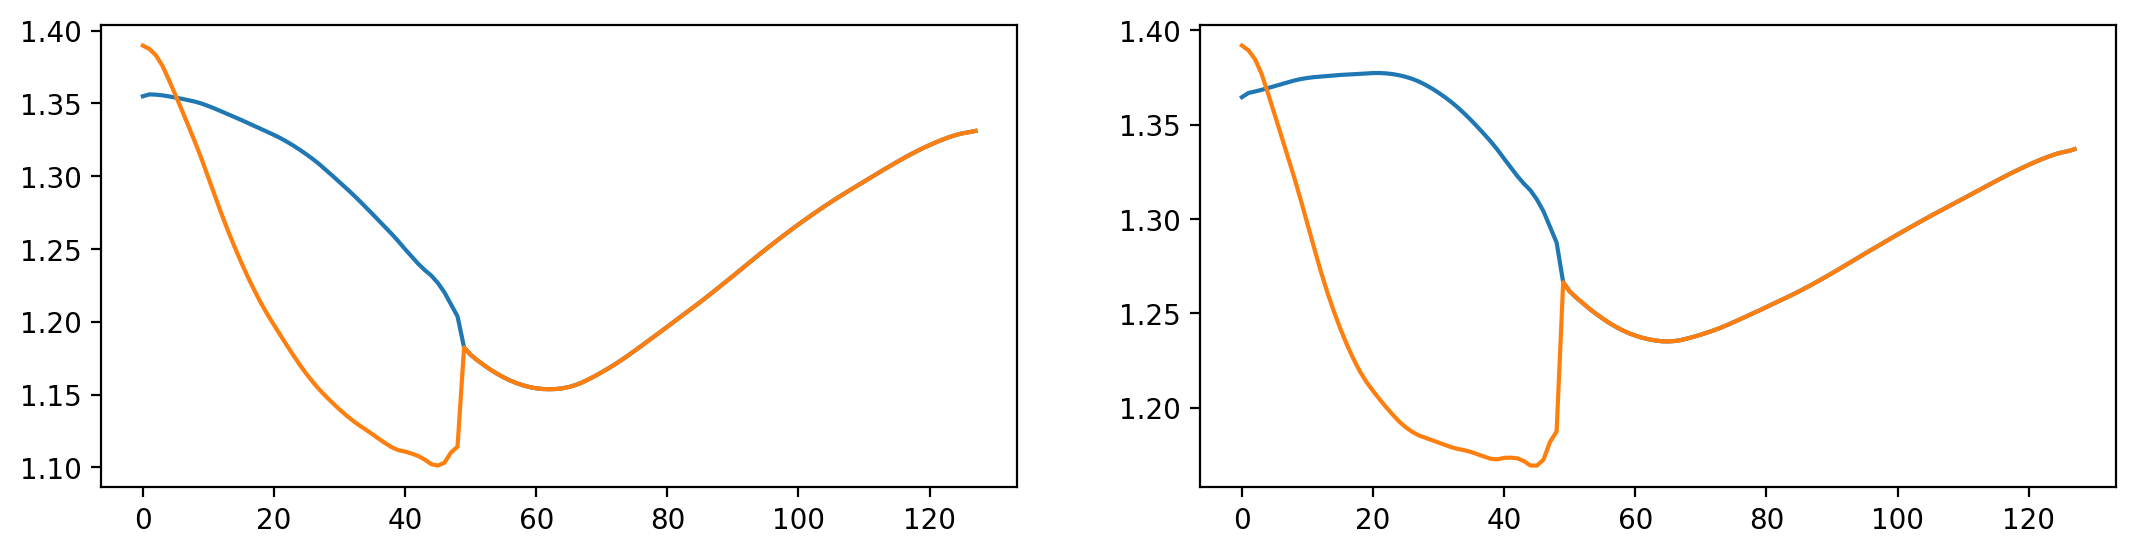

In [157]:
plt.figure(figsize=(13, 3))
plt.subplot(1, 2, 1)
plt.plot(deconv_dat_high.mean(axis=1).mean(axis=1)[t_indices])
plt.plot(deconv_dat_high.mean(axis=1).mean(axis=1)[i_indices])

plt.subplot(1, 2, 2)
plt.plot(deconv_dat_low.mean(axis=1).mean(axis=1)[t_indices])
plt.plot(deconv_dat_low.mean(axis=1).mean(axis=1)[i_indices])

The effect is still prevalent in the large window. Current guess is that the stochastics of the nucleosomes are amplifying the model issue.

Let's zoom in on the 10k window and identify the correlation on a nucleosome level... For the "high" correlation window.

